In [200]:
import numpy as np
import pandas as pd 
import matplotlib.pylab as plt
import seaborn as sns
from pylab import mpl
mpl.rcParams['font.sans-serif'] = ['SimHei']
mpl.rcParams['axes.unicode_minus'] = False

In [118]:
file_data = pd.read_csv('./链家北京租房数据.csv')
file_data = file_data.iloc[:,0:6]
file_data.drop(columns='Unnamed: 0',inplace=True)
file_data

,区域,小区名称,户型,面积(㎡),价格(元/月)
0,东城,万国城MOMA,1室0厅,59.11,10000
1,东城,北官厅胡同2号院,3室0厅,56.92,6000
2,东城,和平里三区,1室1厅,40.57,6900
3,东城,菊儿胡同,2室1厅,57.09,8000
4,东城,交道口北二条35号院,1室1厅,42.67,5500
...,...,...,...,...,...
5768,顺义,怡馨家园,3室1厅,114.03,5500
5769,顺义,旭辉26街区,4室2卫,59.00,5000
5770,顺义,前进花园玉兰苑,3室1厅,92.41,5800
5771,顺义,双裕小区,2室1厅,71.81,4200


In [119]:
file_data.shape

(5773, 5)

In [120]:
file_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5773 entries, 0 to 5772
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   区域       5773 non-null   object 
 1   小区名称     5773 non-null   object 
 2   户型       5773 non-null   object 
 3   面积(㎡)    5773 non-null   float64
 4   价格(元/月)  5773 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 225.6+ KB


In [121]:
file_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5773 entries, 0 to 5772
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   区域       5773 non-null   object 
 1   小区名称     5773 non-null   object 
 2   户型       5773 non-null   object 
 3   面积(㎡)    5773 non-null   float64
 4   价格(元/月)  5773 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 225.6+ KB


In [122]:
file_data.describe()

,面积(㎡),价格(元/月)
count,5773.000000,5773.000000
mean,96.516129,9616.677464
std,61.510085,9367.993801
min,11.630000,566.000000
25%,59.150000,4800.000000
50%,81.950000,6800.000000
75%,112.520000,10500.000000
max,1133.000000,150000.000000


数据基本处理

In [123]:
#重复值检测
file_data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5768    False
5769    False
5770    False
5771    False
5772    False
Length: 5773, dtype: bool

In [124]:
#删除重复值
file_data = file_data.drop_duplicates()

In [125]:
file_data.shape

(5773, 5)

In [126]:
#nan值处理
file_data = file_data.dropna()

In [127]:
file_data.shape

(5773, 5)

In [133]:
house_data = file_data['户型']
temp_list = []
for i in house_data:
    now_info=i.replace('房间','室')
    temp_list.append(now_info)

In [139]:
temp_list
file_data.loc[:,'户型']=temp_list

In [140]:
file_data

,区域,小区名称,户型,面积(㎡),价格(元/月)
0,东城,万国城MOMA,1室0厅,59.11,10000
1,东城,北官厅胡同2号院,3室0厅,56.92,6000
2,东城,和平里三区,1室1厅,40.57,6900
3,东城,菊儿胡同,2室1厅,57.09,8000
4,东城,交道口北二条35号院,1室1厅,42.67,5500
...,...,...,...,...,...
5768,顺义,怡馨家园,3室1厅,114.03,5500
5769,顺义,旭辉26街区,4室2卫,59.00,5000
5770,顺义,前进花园玉兰苑,3室1厅,92.41,5800
5771,顺义,双裕小区,2室1厅,71.81,4200


In [186]:
#区域分析
new_df = pd.DataFrame({'区域':file_data['区域'].unique(),'数量':[0]*13})
new_df

,区域,数量
0,东城,0
1,丰台,0
2,亦庄开发区,0
3,大兴,0
4,房山,0
5,昌平,0
6,朝阳,0
7,海淀,0
8,石景山,0
9,西城,0


In [190]:
group_area = file_data.groupby(by='区域').count()
new_df['数量']=group_area.values
new_df.sort_values(by='数量',ascending=False)
new_df

,区域,数量
0,东城,282
1,丰台,577
2,亦庄开发区,147
3,大兴,362
4,房山,180
5,昌平,347
6,朝阳,1597
7,海淀,605
8,石景山,175
9,西城,442


In [163]:
#户型分析
def all_house(arr):
    key = np.unique(arr)
    result = {}
    for k in key:
        mask = (arr == k)
        arr_new = arr[mask]
        v = arr_new.size
        result[k] = v
    return result

In [191]:
house_info = all_house(house_data)
house_info

{'0室0厅': 1,
 '1室0卫': 10,
 '1室0厅': 244,
 '1室1卫': 126,
 '1室1厅': 844,
 '1室2厅': 13,
 '2室0卫': 1,
 '2室0厅': 23,
 '2室1卫': 120,
 '2室1厅': 2249,
 '2室2卫': 22,
 '2室2厅': 265,
 '2室3厅': 1,
 '3室0卫': 3,
 '3室0厅': 12,
 '3室1卫': 92,
 '3室1厅': 766,
 '3室2卫': 48,
 '3室2厅': 489,
 '3室3卫': 1,
 '3室3厅': 10,
 '4室1卫': 15,
 '4室1厅': 58,
 '4室2卫': 24,
 '4室2厅': 191,
 '4室3卫': 5,
 '4室3厅': 9,
 '4室5厅': 2,
 '5室0卫': 1,
 '5室0厅': 1,
 '5室1卫': 3,
 '5室1厅': 7,
 '5室2卫': 7,
 '5室2厅': 49,
 '5室3卫': 3,
 '5室3厅': 24,
 '5室4厅': 1,
 '5室5厅': 1,
 '6室0厅': 1,
 '6室1卫': 1,
 '6室1厅': 1,
 '6室2厅': 5,
 '6室3卫': 2,
 '6室3厅': 6,
 '6室4卫': 2,
 '7室1厅': 1,
 '7室2厅': 2,
 '7室3厅': 3,
 '7室4厅': 1,
 '8室4厅': 2,
 '9室1厅': 2,
 '9室2厅': 1,
 '9室5厅': 2}

In [197]:
group_house =file_data.groupby(by=file_data['户型']).count()
new_house = pd.DataFrame({'户型':file_data['户型'].unique(),'数量':[0]*53})
new_house['数量']=group_house.values
new_house.sort_values(by='数量',ascending=False)
new_house.drop(new_house[new_house['数量'] < 50].index)
new_house

,户型,数量
0,1室0厅,1
1,3室0厅,10
2,1室1厅,244
3,2室1厅,126
4,5室2厅,844
5,2室2厅,13
6,3室1厅,1
7,2室1卫,23
8,4室1厅,120
9,3室2厅,2249


In [192]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   区域      13 non-null     object
 1   数量      13 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 336.0+ bytes


In [194]:
house_data = dict((key,value) for key,value in house_info.items() if value > 50)

In [195]:
show_houses=pd.DataFrame({'户型':[x for x in house_data.keys()],
                         '数量':[x for x in house_data.values()]})

In [196]:
show_houses

,户型,数量
0,1室0厅,244
1,1室1卫,126
2,1室1厅,844
3,2室1卫,120
4,2室1厅,2249
5,2室2厅,265
6,3室1卫,92
7,3室1厅,766
8,3室2厅,489
9,4室1厅,58


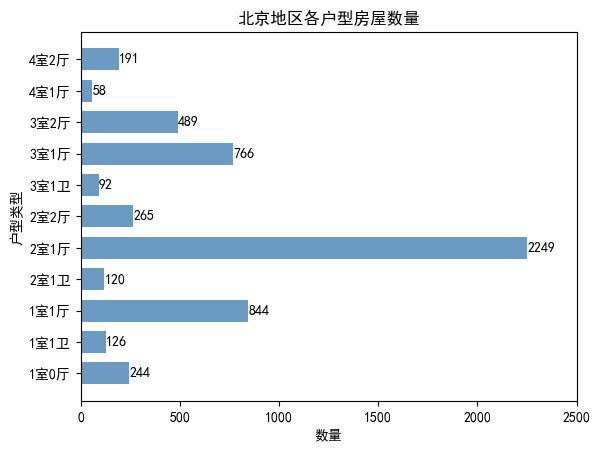

In [201]:
#图形化展示
house_type = show_houses['户型']
house_type_num  = show_houses['数量']
plt.barh(range(11),house_type_num,height=0.7,color='steelblue',alpha=0.8)
plt.yticks(range(11),house_type)
plt.xlim(0,2500)
plt.xlabel('数量')
plt.ylabel('户型类型')
plt.title('北京地区各户型房屋数量')
for x,y in enumerate(house_type_num):
    plt.text(y+2,x-0.1,'%s' % y)
plt.show()

平均租金的分析

In [207]:
df_all = pd.DataFrame({'区域':file_data['区域'].unique(),
             '房租总金额':[0]*13,
             '总面积':[0]*13})


In [210]:
sum_price = file_data['价格(元/月)'].groupby(by=file_data['区域']).sum()
sum_area = file_data['面积(㎡)'].groupby(by=file_data['区域']).sum()

In [211]:
df_all['房租总金额']=sum_price.values
df_all['总面积']=sum_area.values

In [212]:
df_all

,区域,房租总金额,总面积
0,东城,3945550,27353.99
1,丰台,4404893,50922.79
2,亦庄开发区,1318400,15995.53
3,大兴,2286950,35884.15
4,房山,726750,15275.41
5,昌平,2521515,35972.92
6,朝阳,20281396,166921.72
7,海淀,7279350,57210.39
8,石景山,1156500,13956.67
9,西城,5636975,37141.64


In [215]:
#计算各个区域每平方的房租
df_all['每平米(元)'] = round(df_all['房租总金额']/df_all['总面积'],2)

In [216]:
df_all

,区域,房租总金额,总面积,每平米(元)
0,东城,3945550,27353.99,144.24
1,丰台,4404893,50922.79,86.50
2,亦庄开发区,1318400,15995.53,82.42
3,大兴,2286950,35884.15,63.73
4,房山,726750,15275.41,47.58
5,昌平,2521515,35972.92,70.09
6,朝阳,20281396,166921.72,121.50
7,海淀,7279350,57210.39,127.24
8,石景山,1156500,13956.67,82.86
9,西城,5636975,37141.64,151.77


In [217]:
df_merge = pd.merge(new_df,df_all)

In [218]:
df_merge

,区域,数量,房租总金额,总面积,每平米(元)
0,东城,282,3945550,27353.99,144.24
1,丰台,577,4404893,50922.79,86.50
2,亦庄开发区,147,1318400,15995.53,82.42
3,大兴,362,2286950,35884.15,63.73
4,房山,180,726750,15275.41,47.58
5,昌平,347,2521515,35972.92,70.09
6,朝阳,1597,20281396,166921.72,121.50
7,海淀,605,7279350,57210.39,127.24
8,石景山,175,1156500,13956.67,82.86
9,西城,442,5636975,37141.64,151.77


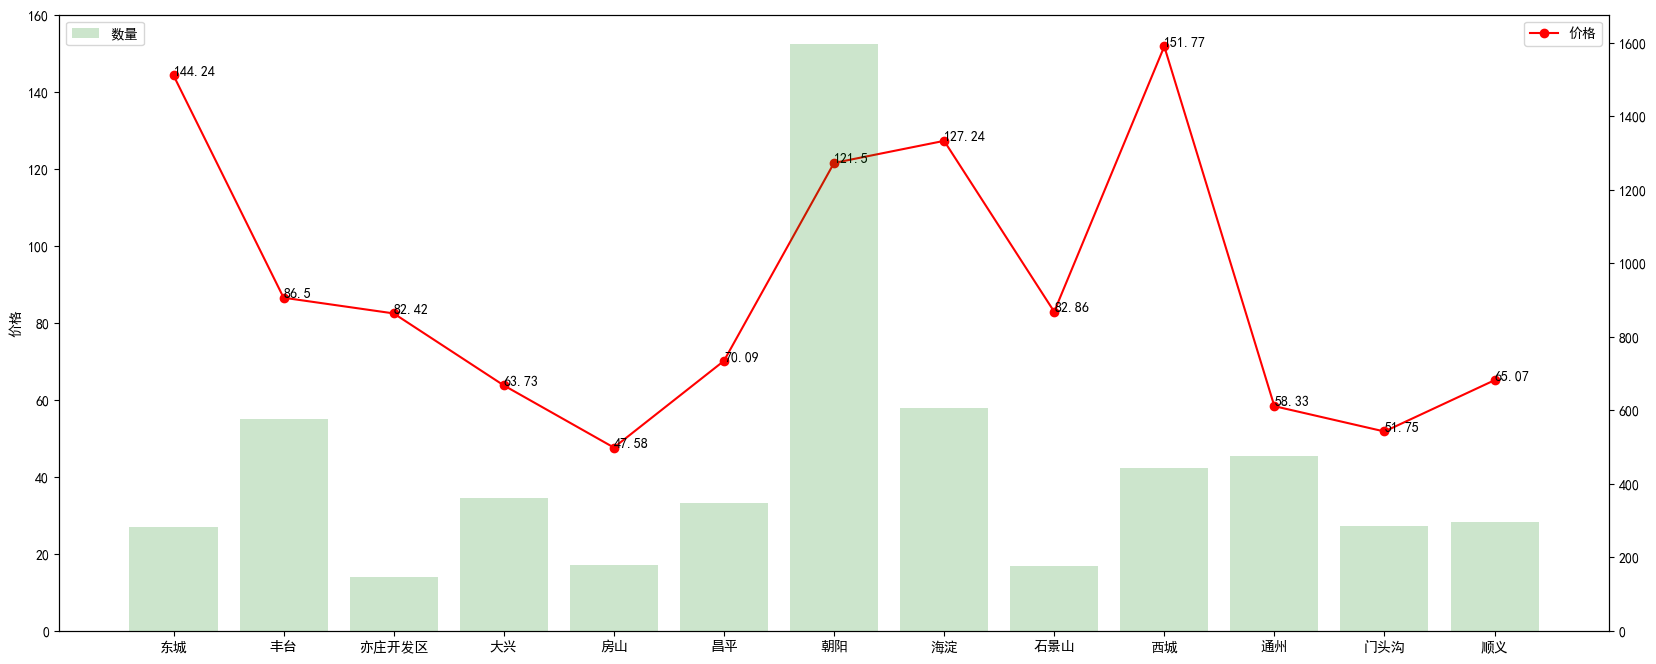

In [236]:
#图形化
num = df_merge['数量']
price = df_merge['每平米(元)']
lx = df_merge['区域']
l = [i for i in range(13)]
fig = plt.figure(figsize=(20,8),dpi=100)
#折线图
ax1 = fig.add_subplot(111)
ax1.plot(l,price,'or-',label = '价格')
for i,(_x,_y) in enumerate(zip(l,price)):
    plt.text(_x,_y,price[i])
ax1.set_ylim(0,160)
ax1.set_ylabel('价格')
plt.legend(loc='upper right')

#条形图
ax2 = ax1.twinx()
plt.bar(l,num,label='数量',alpha = 0.2,color = 'g')
plt.legend(loc='upper left')
plt.xticks(l,lx)



plt.show()

面积区间的基础分析

In [243]:
#查看房屋面积最大和最小
print('房屋最大面积是{}平方米'.format(file_data['面积(㎡)'].max()))
print('房屋最小面积是{}平方米'.format(file_data['面积(㎡)'].min()))

房屋最大面积是1133.0平方米
房屋最小面积是11.63平方米


In [246]:
#查看房租最大和最小
print('房租最高价格是每月{}元'.format(file_data['价格(元/月)'].max()))
print('房租最低价格是每月{}元'.format(file_data['价格(元/月)'].min()))

房租最高价格是每月150000元
房租最低价格是每月566元


In [253]:
#面积划分
area_divide = [1,30,50,70,90,120,140,160,1200]
area_cut = pd.cut(list(file_data['面积(㎡)']),area_divide)

In [254]:
area_cut_num = area_cut.describe()
area_cut_num

,counts,freqs
categories,,
"(1, 30]",41,0.007102
"(30, 50]",710,0.122986
"(50, 70]",1566,0.271263
"(70, 90]",1094,0.189503
"(90, 120]",1082,0.187424
"(120, 140]",381,0.065997
"(140, 160]",274,0.047462
"(160, 1200]",625,0.108263


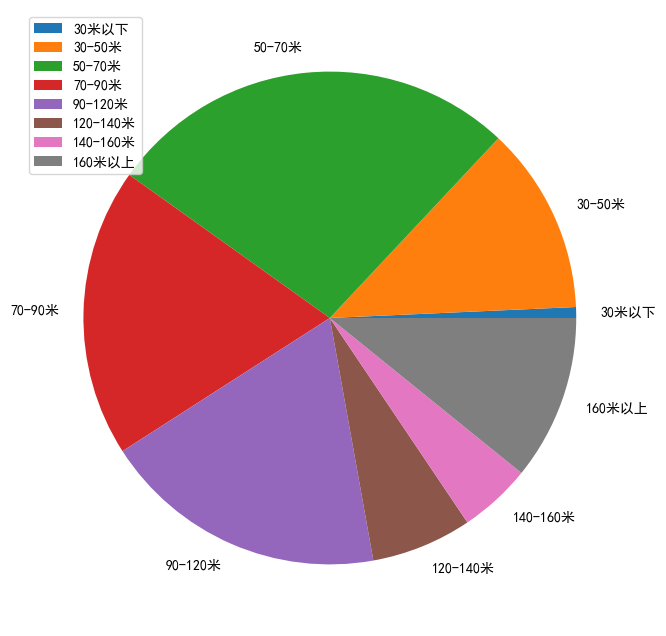

In [255]:
#图像化
area_per = (area_cut_num['freqs'].values)*100
labels = ['30米以下','30-50米','50-70米','70-90米','90-120米','120-140米','140-160米','160米以上']
plt.figure(figsize=(20,8),dpi=100)
plt.axes()
plt.pie(x=area_per,labels=labels)
plt.legend()
plt.show()